# RELATÓRIO GERENCIAL — FATORES RELACIONADOS À RECEITA

## 1. Introdução

Este relatório apresenta a análise dos dados de mídia com foco em identificar **quais fatores estão relacionados à receita** observada na base.

A análise considera informações de plataformas, investimento, etapa do funil, período, campanhas, motivos de atribuição, pedidos, visitas, impressões e cliques.

O objetivo é organizar os resultados já obtidos na análise técnica em uma visão gerencial, facilitando a identificação de onde a receita está concentrada e quais variáveis apresentam relação com ela.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Reconstrução da base "tratada" (mesma lógica do notebook técnico),
# para que este relatório possa ser executado de forma independente.
df = pd.read_csv('bq-results-20260904-205126-1788555238314.csv')
df['report_date'] = pd.to_datetime(df['report_date'].str.strip(), format="%Y-%m-%d")

plataformas_sem_receita = ['Awin', 'Kayak', 'Skyscanner', 'DV360', 'Vivo']
df_receita = df[~df['platform'].isin(plataformas_sem_receita)]

df_receita_sem_pct = df_receita.drop(columns=[
    'pct_receita_assertiva', 'pct_receita_anuncio_ambiguo',
    'pct_receita_assertiva_alta', 'pct_investimento_anuncio'
])

numericas_zero = [
    "receita", "orders", "visits", "investimento", "impressions", "clicks",
    "receita_safe_ad", "receita_excecao_manual", "receita_pmax_sem_anuncio",
    "receita_por_nome_campanha", "receita_outro", "receita_anuncio_ambiguo", "receita_nao_casado",
    "investimento_anuncio", "investimento_campanha",
]
tratada = df_receita_sem_pct.copy()
for col in numericas_zero:
    tratada[col] = tratada[col].fillna(0)

tratada["motivos_receita"] = tratada["motivos_receita"].fillna("sem_receita")
tratada["motivos_investimento"] = tratada["motivos_investimento"].fillna("sem_investimento")

tratada["roas"] = tratada["receita"] / tratada["investimento"].replace(0, np.nan)
tratada["roas"] = tratada["roas"].fillna(0)

tratada["mes"] = tratada["report_date"].dt.month
tratada["ano"] = tratada["report_date"].dt.year
tratada["ano_mes"] = tratada["report_date"].dt.to_period("M").astype(str)

tratada = tratada[tratada['funnel_stage'] != 'NÃO IDENTIFICADO']

## 2. Validação e tratamento da base

Antes das análises de negócio, a base passou por etapas de validação e tratamento.

Foram verificadas a estrutura dos dados, valores nulos, categorias não identificadas e registros relacionados à receita e ao investimento.

Algumas plataformas foram desconsideradas especificamente nas análises de receita por não apresentarem informação suficiente para uma comparação adequada:

- **Awin:** todas as linhas apresentam receita nula;
- **Kayak:** todas as linhas apresentam receita nula;
- **Skyscanner:** todas as linhas apresentam receita nula;
- **DV360:** apresenta apenas valores 0 ou nulos de receita;
- **Vivo:** possui apenas um valor diferente de 0 ou nulo.

Essas plataformas não foram consideradas nas análises.

Também foram realizados tratamentos nas datas, variáveis categóricas e variáveis numéricas. As datas foram convertidas para `datetime`, e foram criadas dimensões de mês, ano e ano-mês.

As linhas com `funnel_stage` igual a **"NÃO IDENTIFICADO"** foram removidas. Eram 61 linhas, uma parcela pequena da base, mas sem classificação adequada para as análises por etapa do funil.

A base tratada foi utilizada nas análises gerenciais apresentadas a seguir.

## 3. Visão geral da receita

A receita apresenta **dispersão extremamente elevada**.

O período analisado vai de **03/11/2025 a 31/08/2026**, aproximadamente 10 meses.

A receita possui:

- **média:** R$ 42.048,01;
- **mediana:** R$ 0,00;
- **terceiro quartil:** R$ 2.878,88;
- **valor máximo:** R$ 4.265.516,27;
- **desvio padrão:** R$ 280.206,84.

A diferença entre média e mediana mostra que grande parte das linhas não apresenta receita, enquanto poucas linhas concentram valores muito elevados.


### Outras variáveis relacionadas

**Pedidos (`orders`)**

A média é de 24,37 pedidos, enquanto a mediana é 0. O valor máximo é 2.412 pedidos, mostrando forte concentração em poucas linhas.

**Visitas (`visits`)**

A média é de 592,57 visitas e a mediana é 11. O valor máximo é 42.968, indicando forte assimetria e presença de valores extremos.

**Investimento (`investimento`)**

A média é de R$ 3.096,61 e a mediana é de R$ 242,31. O desvio padrão é de R$ 11.907,54, indicando grande dispersão entre os valores investidos.

Essa distribuição da receita é importante para a interpretação das demais análises, pois valores extremos podem concentrar grande parte do resultado financeiro.

## 4. Receita e investimento por plataforma

A análise por plataforma busca verificar onde estão concentrados a receita e o investimento.

O resultado agregado mostra que:

- **Google Ads** concentra **76,22% do investimento** e **84,82% da receita**;
- **Bing Ads** representa **17,38% do investimento** e **14,74% da receita**;
- as demais plataformas possuem participações menores nesses indicadores.

As 20 maiores linhas de receita pertencem ao **Google Ads**. As 20 maiores linhas de investimento também pertencem ao Google Ads.

Entretanto, apenas **2 das 20 maiores linhas de receita** também aparecem entre as 20 maiores linhas de investimento. Isso mostra que as maiores linhas de receita e as maiores linhas de investimento não são necessariamente as mesmas.

Na análise agregada, Google Ads e Bing Ads concentram a maior parte da receita observada.

O ROAS complementa essa leitura ao relacionar receita e investimento. Ele deve ser interpretado como retorno sobre a mídia registrada na base, e não como lucro da operação.

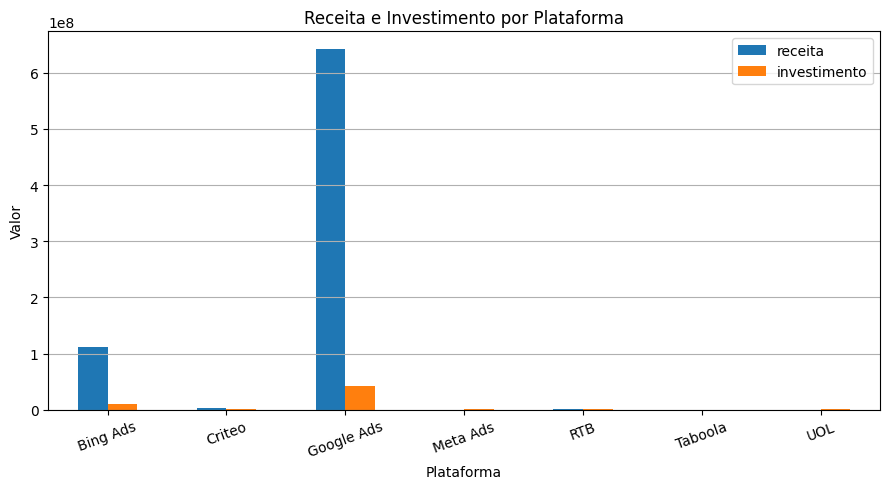

In [4]:
# Receita e investimento por plataforma

plataforma_resumo = tratada.groupby("platform")[["receita", "investimento"]].sum()

ax = plataforma_resumo.plot(
    kind="bar",
    figsize=(9, 5)
)

ax.set_title("Receita e Investimento por Plataforma")
ax.set_xlabel("Plataforma")
ax.set_ylabel("Valor")
plt.xticks(rotation=20)
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

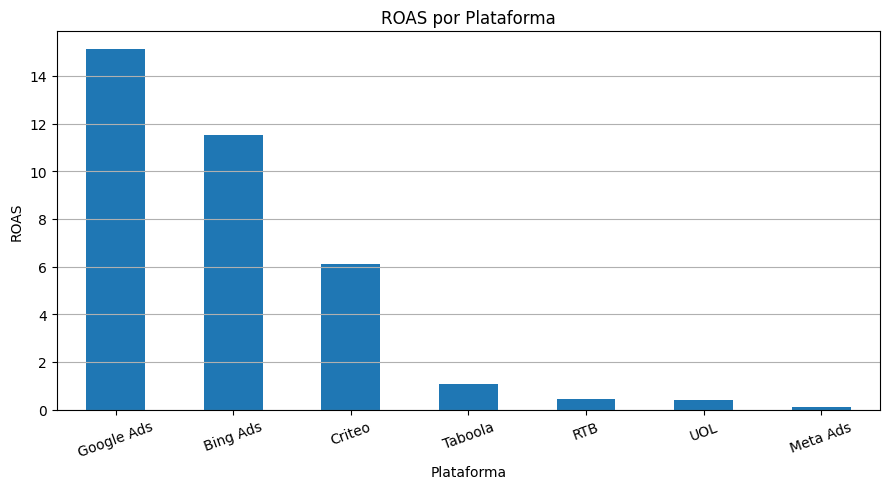

In [5]:
# ROAS por plataforma

roas_plataforma = (
    tratada.groupby("platform")[["receita", "investimento"]]
    .sum()
)

roas_plataforma["roas"] = (
    roas_plataforma["receita"] /
    roas_plataforma["investimento"]
)

roas_plataforma["roas"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("ROAS por Plataforma")
plt.xlabel("Plataforma")
plt.ylabel("ROAS")
plt.xticks(rotation=20)
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

## 5. Receita ao longo do tempo

A análise temporal permite verificar como a receita, o investimento, os pedidos e as visitas se comportam durante o período.

A análise por mês mostrou que **agosto de 2026 apresentou a maior receita e o maior ROAS**.

Já **novembro apresentou a menor receita e o menor ROAS devido ao fato de ser um mês incompleto**.

A análise temporal mostra, portanto, que a receita não se distribui de maneira uniforme ao longo do período.

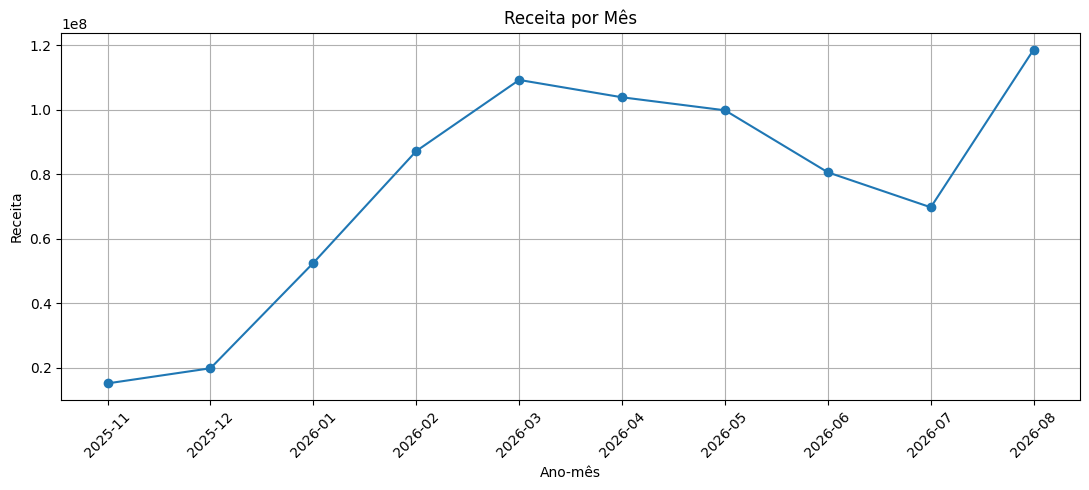

In [6]:
# Receita mensal

receita_mensal = tratada.groupby("ano_mes")["receita"].sum()

plt.figure(figsize=(11, 5))
plt.plot(receita_mensal.index, receita_mensal.values, marker="o")
plt.title("Receita por Mês")
plt.xlabel("Ano-mês")
plt.ylabel("Receita")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

## 6. Receita por etapa do funil

A análise do funil verifica onde a receita atribuída está concentrada e como o investimento e o ROAS se comportam em cada etapa.

A **etapa de conversão concentra quase 100% da receita atribuída**, aproximadamente **R$ 756 milhões** na base tratada.

Awareness apresenta receita de zero.

Consideração apresenta receita de R$ 206.527

Na análise por plataforma e etapa:

- Awareness não apresentou receita atribuída;
- Consideração não apresentou receita nas plataformas RTB e Meta Ads;
- a maior parte das linhas com maior receita pertence à etapa de conversão.

Esse resultado representa a **atribuição registrada na base**. Ele não permite concluir, isoladamente, que Awareness ou Consideração não tenham participado da jornada do consumidor.

In [14]:
receita_funil = tratada.groupby("funnel_stage")["receita"].sum().sort_values(ascending=False)
receita_funil


funnel_stage
Conversão      756321266.46
Consideração      206527.59
Awareness              0.00
Name: receita, dtype: float64

In [16]:
funil_resumo = tratada.groupby("funnel_stage")[["receita", "investimento"]].sum()
funil_resumo

,receita,investimento
funnel_stage,,
Awareness,0.00,1360533.66
Consideração,206527.59,2021735.24
Conversão,756321266.46,52331921.08


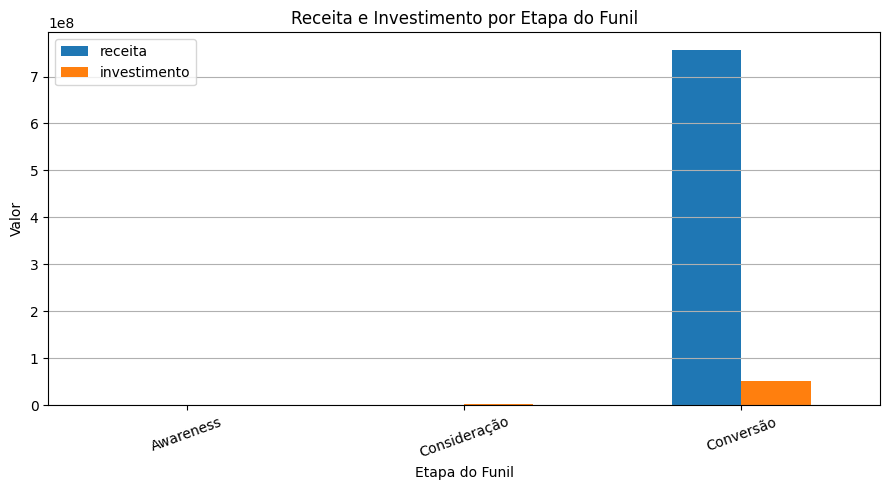

In [8]:
# Receita e investimento por etapa do funil

funil_resumo = tratada.groupby("funnel_stage")[["receita", "investimento"]].sum()

ax = funil_resumo.plot(
    kind="bar",
    figsize=(9, 5)
)

ax.set_title("Receita e Investimento por Etapa do Funil")
ax.set_xlabel("Etapa do Funil")
ax.set_ylabel("Valor")
plt.xticks(rotation=20)
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

## 7. Motivos de atribuição da receita

A análise dos motivos da receita permite entender como o valor financeiro foi classificado na base.

A categoria **`por_nome_campanha`** representa a maior parte da receita atribuída.

Também aparecem categorias como:

- `receita_anuncio_ambiguo`;
- `receita_safe_ad`;
- `receita_excecao_manual`;
- `receita_pmax_sem_anuncio`;
- `sem_receita` (motivo atribuído às linhas sem receita).

A categoria `sem_receita` possui grande quantidade de linhas, mas contribuição zero de receita, conforme esperado.

As combinações classificadas como `anuncio_ambiguo` apresentam ROAS mais instável em alguns casos, com valores entre 32 e 39, indicando concentração de valor em poucas linhas. Esse comportamento deve ser interpretado junto aos possíveis outliers já identificados na distribuição da receita.

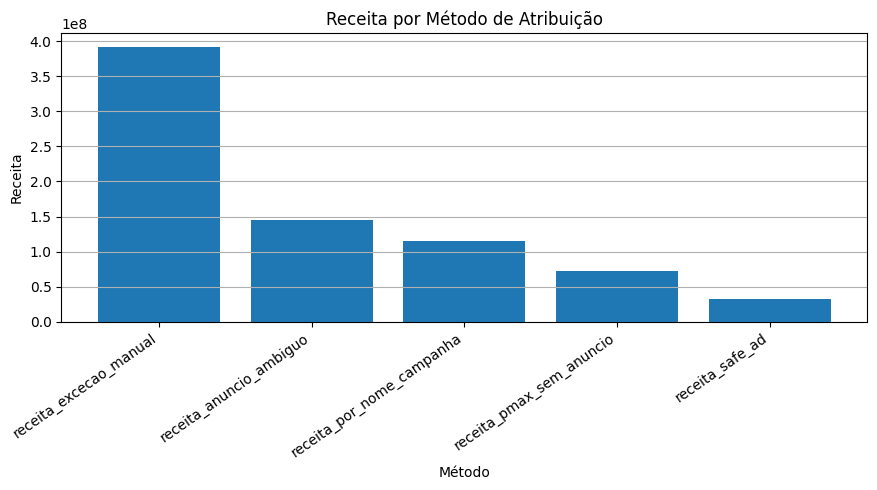

In [9]:
# Participação da receita por método de atribuição

metodos = [
    "receita_safe_ad",
    "receita_excecao_manual",
    "receita_pmax_sem_anuncio",
    "receita_por_nome_campanha",
    "receita_anuncio_ambiguo"
]

mix_atribuicao = tratada[metodos].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(mix_atribuicao.index, mix_atribuicao.values)
plt.title("Receita por Método de Atribuição")
plt.xlabel("Método")
plt.ylabel("Receita")
plt.xticks(rotation=35, ha="right")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

## 8. Receita por grupo e nome de campanha

O agrupamento por campanha permite identificar onde a receita está concentrada em níveis mais específicos.

### Grupo de campanha

**`AON-MARCA-BRD`** é o maior grupo em receita absoluta.

Já **`MARCA`** apresenta ROAS de **57,6**, com menor investimento.

Essa diferença mostra que volume de receita e eficiência relativa são indicadores diferentes. O grupo com maior receita não precisa ser o mesmo grupo com maior ROAS.

### Nome de campanha

No nível de campanha, **`SEARCH_LF_MARCA`** e **`SEARCH_LF_AON-MARCA-BRD`** apresentam os maiores valores de receita e ROAS.

Muitas dessas campanhas possuem aproximadamente 300 linhas, o que pode indicar presença contínua ao longo dos dias analisados.

A quantidade de linhas deve ser considerada porque campanhas presentes durante mais dias podem acumular mais receita simplesmente por possuírem maior período de exposição.

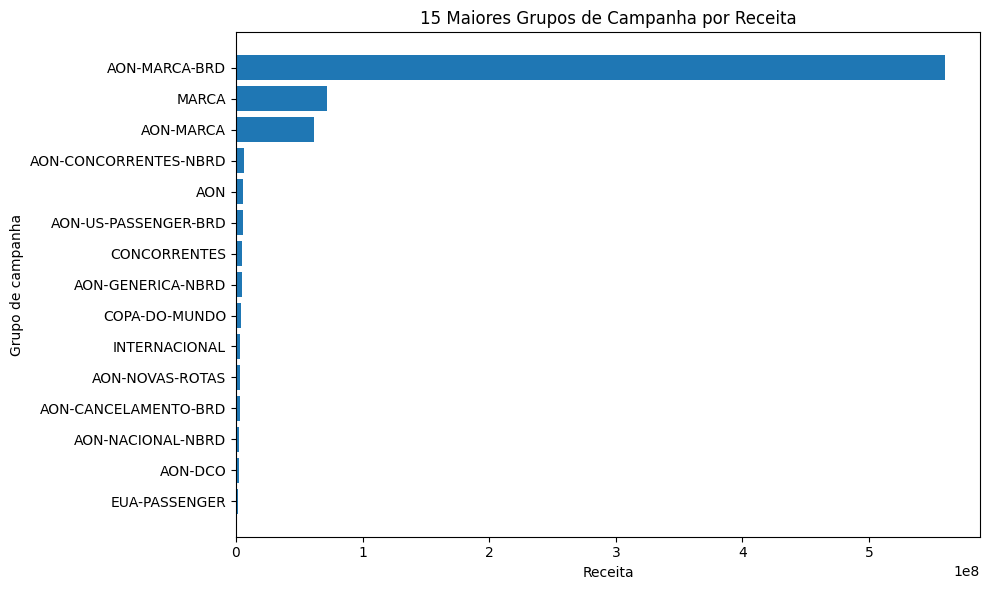

In [10]:
# 15 maiores grupos de campanha por receita

grupo_campanha = (
    tratada.groupby("campaign_group")
    .agg(
        receita=("receita", "sum"),
        investimento=("investimento", "sum")
    )
)

grupo_campanha["roas"] = (
    grupo_campanha["receita"] /
    grupo_campanha["investimento"].replace(0, pd.NA)
)

grupo_campanha = grupo_campanha.sort_values(
    "receita",
    ascending=False
).head(15)

plt.figure(figsize=(10, 6))
plt.barh(
    grupo_campanha.index[::-1],
    grupo_campanha["receita"][::-1]
)
plt.title("15 Maiores Grupos de Campanha por Receita")
plt.xlabel("Receita")
plt.ylabel("Grupo de campanha")
plt.tight_layout()
plt.show()

## 9. Receita por dia da semana

A análise por dia da semana compara o volume acumulado e a média por ocorrência de cada dia.

Na base analisada:

- sábado e domingo apresentam receita total inferior aos dias úteis;
- segunda-feira, terça-feira e quarta-feira concentram os maiores valores agregados.

Para essa comparação, a média de receita por dia e o ROAS são importantes, pois os totais podem ser influenciados pela quantidade de ocorrências de cada dia no período.

Esse resultado é descritivo e deve ser interpretado em conjunto com investimento, campanhas ativas e composição das plataformas.

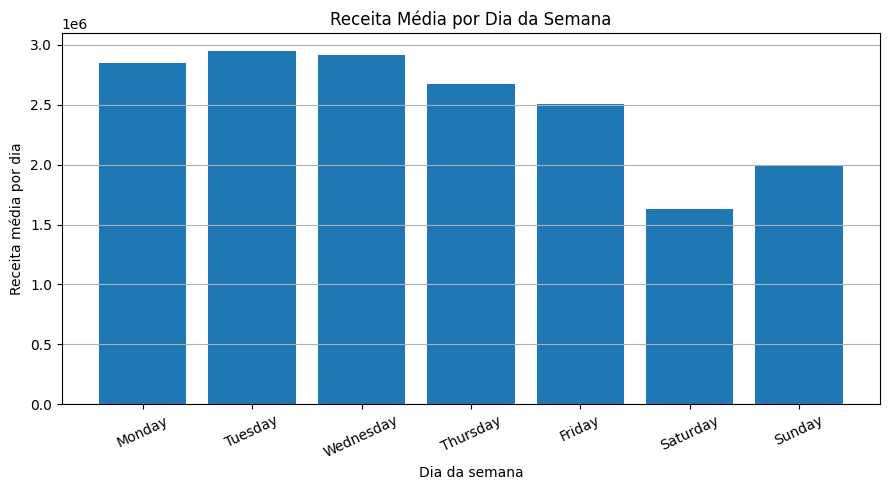

In [11]:
# Receita média por dia da semana

tratada["dia_semana"] = tratada["report_date"].dt.day_name()

ordem_dias = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

receita_dia_semana = tratada.groupby("dia_semana").agg(
    dias=("report_date", "nunique"),
    receita=("receita", "sum"),
    investimento=("investimento", "sum")
)

receita_dia_semana["receita_media_por_dia"] = (
    receita_dia_semana["receita"] /
    receita_dia_semana["dias"]
)

receita_dia_semana = receita_dia_semana.reindex(ordem_dias)

plt.figure(figsize=(9, 5))
plt.bar(
    receita_dia_semana.index,
    receita_dia_semana["receita_media_por_dia"]
)
plt.title("Receita Média por Dia da Semana")
plt.xlabel("Dia da semana")
plt.ylabel("Receita média por dia")
plt.xticks(rotation=25)
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

## 10. Relação entre variáveis e receita

A correlação foi utilizada para medir a associação linear entre variáveis numéricas e receita.

Os resultados obtidos mostram:

- **`orders` e `visits` apresentam correlação muito alta com a receita**;
- **`investimento` e `clicks` apresentam correlação moderada**;
- **`impressions` apresenta correlação próxima de zero**.

A relação elevada entre `orders` e receita é esperada porque pedidos representam diretamente o processo de conversão.

A relação entre investimento, cliques e receita indica que essas variáveis variam conjuntamente na base analisada, mas a correlação não demonstra causalidade.

A baixa correlação de impressões indica que, neste conjunto de dados, a quantidade de impressões apresenta pouca relação linear com a receita.

As correlações também podem ser influenciadas por escala, outliers e relações indiretas entre as variáveis.

Uma hipótese provável para essa baixa correlação é que `impressions` é uma métrica de topo de funil (alcance/exposição ao anúncio), enquanto a receita depende de etapas posteriores da jornada (clique, visita, pedido). É esperado que uma métrica de alcance sozinha tenha pouca relação direta com o resultado financeiro final.

In [17]:
num_cols = ['receita', 'orders', 'visits', 'investimento', 'impressions', 'clicks']
tratada[num_cols].corr()['receita'].sort_values(ascending=False)

receita        1.00
orders         1.00
visits         0.98
investimento   0.69
clicks         0.61
impressions    0.01
Name: receita, dtype: float64

# 11. Conclusão

A análise mostrou que a receita apresenta **forte concentração e grande dispersão**, com uma diferença significativa entre média, mediana e valores máximos.

Entre as dimensões analisadas, a receita está concentrada principalmente em determinadas **plataformas, grupos e campanhas**. Google Ads e Bing Ads representam grande parte do volume financeiro observado, enquanto alguns grupos e nomes de campanha concentram valores elevados.

Na dimensão temporal, a receita varia significativamente entre os meses e dias. **Agosto de 2026** apresentou a maior receita e o maior ROAS no recorte mensal, enquanto o início de **novembro de 2025** apresentou valores menores no recorte diário analisado.

No funil, a receita atribuída está concentrada na etapa de **conversão**. Esse resultado representa a atribuição registrada na base e não permite concluir, isoladamente, que as demais etapas não tenham participado da jornada do consumidor.

Na análise das campanhas, `AON-MARCA-BRD` apresenta a maior receita absoluta entre os grupos.

Dessa forma, os principais fatores relacionados à receita na base são observados nas dimensões de **plataforma, investimento, campanhas, etapa do funil, período e variáveis de tráfego/conversão**. As relações apresentadas são descritivas e não devem ser interpretadas isoladamente como relações de causa e efeito.